In [1]:
import numpy as np
import os
import pickle
import torch
import matplotlib.pyplot as plt
import math
import matplotlib.collections as mcoll
from scipy.interpolate import interp1d
import matplotlib.cm as cm
import networkx as nx

In [2]:
def extract_coordinates_from_graph(graph_file_path):
    """
    Extracts coordinates from a graph file and returns a dictionary
    with ascending indices as keys and np.array([x,y]) as values.
    
    Parameters:
    - graph_file_path: Path to the graph file.
    
    Returns:
    - A dictionary with indices as keys and coordinate arrays as values.
    """
    # Load the graph from the file
    with open(graph_file_path, 'rb') as file:
        graph = pickle.load(file)
    
    # Initialize the output dictionary and an index counter
    coordinates_dict = {}    
    # Iterate through each node in the graph
    for node, data in graph.nodes(data=True):
        # Extract (x, z, y) coordinates and convert to (x, y)
        x, _, y = data['point']
        # Store the (x, y) coordinates in the dictionary
        coordinates_dict[node] = np.array([x, y])
    
    return coordinates_dict

In [3]:
path_to_run = "/vision/asomaya1/active-rir/runs"
scene = "wc2JMjhGNzB"
episode = "16322"
run = "SD_CNA_v2policy"

metadata_path = "/vision/asomaya1/active-rir/data/metadata/mp3d"
graph_path = os.path.join(metadata_path, scene, "graph.pkl")
points_path = os.path.join(metadata_path, scene, "points.txt")

use_points = False

In [4]:
def plot_spectrograms_grid(tensor):
    """
    Plots a grid of log spectrograms for the first channel of each spectrogram in the tensor.

    Args:
    tensor (np.array): A 4D numpy array of shape (60, 256, 259, 2) representing 60 2-channel spectrograms.
    """
    # Create a 20x3 subplot grid
    fig, axes = plt.subplots(5, 3, figsize=(10, 30))

    # Iterate through the tensor and plot each spectrogram's first channel
    images = []
    for i in range(5):
        for j in range(3):
            index = i * 3 + j
            if index < tensor.shape[0]:
                pred_spect_mag = torch.exp(tensor[index, :, :, 0])\
                                            - 1e-8
                im = axes[i, j].imshow(pred_spect_mag, aspect='auto', origin='lower')
                axes[i, j].imshow(pred_spect_mag, aspect='auto', origin='lower')
                axes[i, j].set_title(f'Spectrogram {index+1}')
                axes[i, j].axis('off')
                images.append(im)
            else:
                axes[i, j].axis('off')  # Turn off axes for grids with no data

    fig.colorbar(images[-1], ax=axes.ravel().tolist(), orientation='horizontal', pad=0.02)
    plt.tight_layout()
    return fig

In [5]:
# Function to plot RGB, Depth, and both channels of Spectrogram
def plot_rgb_depth_spect(rgb, depth, spect):
    fig, axes = plt.subplots(1, 4, figsize=(15, 3))  # Adjusted for 5 subplots

    # Normalize RGB image to [0, 1]
    normalized_rgb = rgb / 255.0

    # RGB image
    axes[0].imshow(normalized_rgb)
    axes[0].set_title('RGB')
    axes[0].axis('off')

    # Depth image
    depth_image = depth.numpy()
    axes[1].imshow(depth_image, cmap='gray')
    axes[1].set_title('Depth')
    axes[1].axis('off')

    # Spectrogram Channel 1
    axes[2].imshow(spect[:, :, 0].T, aspect='auto')
    axes[2].set_title('Spectrogram Ch1')
    axes[2].axis('off')

    # Spectrogram Channel 2
    axes[3].imshow(spect[:, :, 1].T, aspect='auto')
    axes[3].set_title('Spectrogram Ch2')
    axes[3].axis('off')

    plt.tight_layout()
    return fig

In [6]:
# Function to plot poses with orientation
def plot_poses_with_orientation(poses, graph_x_coords, graph_y_coords, plot_line=True, pad=10):
    fig, ax = plt.subplots(figsize=(6, 6))
    arrow_length = 0.5  # Fixed arrow length

    # Extracting x and y coordinates
    x_coords = [-pose[3] for pose in poses]
    y_coords = [pose[2] for pose in poses]

    if plot_line:
        # Interpolating for smoothness
        num_points = 300  # Number of points for interpolation
        time = np.linspace(0, 1, len(poses))
        time_smooth = np.linspace(0, 1, num_points)
        f_interp_x = interp1d(time, x_coords, kind='cubic')
        f_interp_y = interp1d(time, y_coords, kind='cubic')

        x_smooth = f_interp_x(time_smooth)
        y_smooth = f_interp_y(time_smooth)


        # Create a color map for the line
        norm = plt.Normalize(0, 1)
        points = np.array([x_smooth, y_smooth]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = mcoll.LineCollection(segments, cmap='viridis', norm=norm)
        lc.set_array(time_smooth)
        ax.add_collection(lc)

    # Get a colormap for the arrows and dots
    cmap = cm.get_cmap('Greys')

    # Iterate over poses with index
    for index, pose in enumerate(poses):
        x, y, _, _, theta = pose  # Assuming the pose format is [x, y, theta]
        y = -y

        # Calculate color based on index
        color = cmap(float(index)+1 / len(poses))

        # Plot pose location with varying color
        ax.plot(x, y, 'o')  # Pose location
        ax.plot(graph_x_coords, graph_y_coords, 'x')

        # Calculating arrow direction based on theta
        dx = arrow_length * math.cos(theta)
        dy = arrow_length * math.sin(theta)

        # Drawing arrow with fixed size and varying color
        ax.arrow(x, y, dx, dy, head_width=0.2, head_length=0.3, fc=color, ec=color)

    ax.set_title('Poses with Orientation')
    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.grid(True)
    # Adjust axis limits to make the plot square
    x_range = 10#max(x_coords) - min(x_coords) + pad
    y_range = 10#max(y_coords) - min(y_coords) + pad
    max_range = 25 #max(x_range, y_range) / 2

    mid_x = 0 #(max(x_coords) + min(x_coords)) / 2
    mid_y = 0 #(max(y_coords) + min(y_coords)) / 2

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)

    plt.tight_layout()
    return fig

In [7]:
""" # Function to translate and rotate the coordinates
def transform_coordinates(data, translate_to_origin):
    transformed_data = {}
    for key, value in data.items():
        # Translate
        translated = value - translate_to_origin
        # Rotate 90 degrees clockwise
        # Rotation matrix for 90 degrees clockwise
        rotation_matrix = np.array([[0, 1], [-1, 0]])
        rotated = np.dot(rotation_matrix, translated)
        transformed_data[key] = rotated

    x_coords = [coord[0] for coord in transformed_data.values()]
    y_coords = [coord[1] for coord in transformed_data.values()]
    return x_coords, y_coords, transformed_data """

' # Function to translate and rotate the coordinates\ndef transform_coordinates(data, translate_to_origin):\n    transformed_data = {}\n    for key, value in data.items():\n        # Translate\n        translated = value - translate_to_origin\n        # Rotate 90 degrees clockwise\n        # Rotation matrix for 90 degrees clockwise\n        rotation_matrix = np.array([[0, 1], [-1, 0]])\n        rotated = np.dot(rotation_matrix, translated)\n        transformed_data[key] = rotated\n\n    x_coords = [coord[0] for coord in transformed_data.values()]\n    y_coords = [coord[1] for coord in transformed_data.values()]\n    return x_coords, y_coords, transformed_data '

In [8]:
import numpy as np

def transform_coordinates(data, translate_to_origin, rotation_angle):
    transformed_data = {}
    # Determine rotation matrix based on the rotation_angle
    if rotation_angle == 0:
        rotation_matrix = np.array([[1, 0], [0, 1]])
    elif rotation_angle == 90:
        rotation_matrix = np.array([[0, 1], [-1, 0]])
    elif rotation_angle == 180:
        rotation_matrix = np.array([[-1, 0], [0, -1]])
    elif rotation_angle == 270:
        rotation_matrix = np.array([[0, -1], [1, 0]])
    else:
        raise ValueError("Rotation angle must be one of the following: 0, 90, 180, 270.")

    for key, value in data.items():
        # Translate
        translated = value - translate_to_origin
        # Rotate according to the specified angle
        rotated = [-np.dot(rotation_matrix, translated)[0], np.dot(rotation_matrix, translated)[1]]
        transformed_data[key] = rotated

    x_coords = [coord[0] for coord in transformed_data.values()]
    y_coords = [coord[1] for coord in transformed_data.values()]
    return x_coords, y_coords, transformed_data


In [9]:
#Graph.pkl points:
context_obs_path = os.path.join(path_to_run, run, "tb", f'context_{scene}_{episode}.pkl')
with open(context_obs_path, 'rb') as file:
    loaded_list = pickle.load(file)

loaded_list, query_poses, pred_rirs = loaded_list
pred_rirs = pred_rirs.cpu().squeeze()

coords = extract_coordinates_from_graph(graph_path)

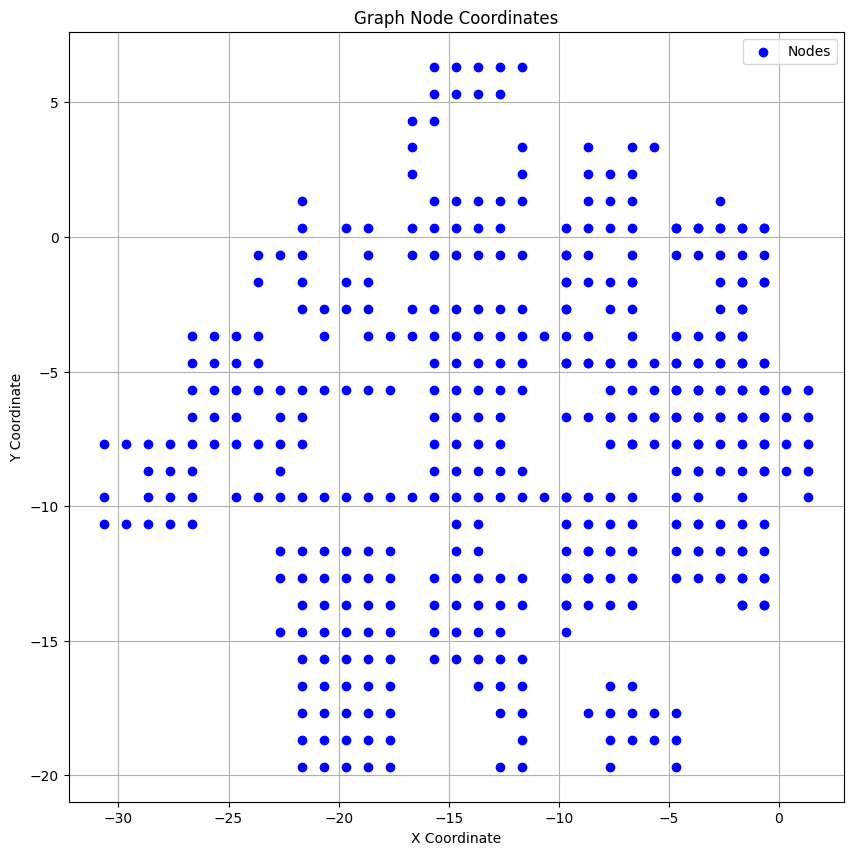

In [10]:
x_coords = [coord[0] for coord in coords.values()]
y_coords = [coord[1] for coord in coords.values()]

# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x_coords, y_coords, c='blue', label='Nodes')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Graph Node Coordinates')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
#points.txt points:
with open(points_path, "r") as f:
    lines = f.readlines()
points_coords = [x.replace("\n", "").split("\t") for x in lines]
positions = dict()
for row in points_coords:
    readout = [float(xyz) for xyz in row[1:]]
    positions[row[0]] = [readout[0], -readout[1]]

points_x_coords = [coord[0] for coord in positions.values()]
points_y_coords = [coord[1] for coord in positions.values()]

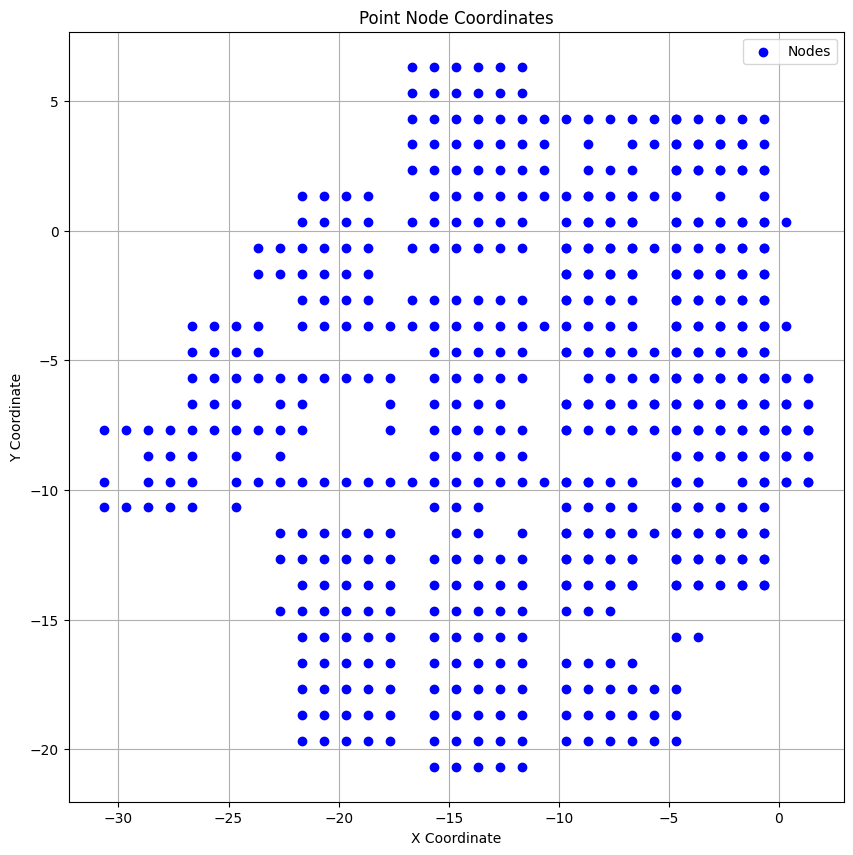

In [12]:
# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(points_x_coords, points_y_coords, c='blue', label='Nodes')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Point Node Coordinates')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Point to translate to (0,0):
#translate_to_origin = np.array([-8.775693, 4.179415]) q9CiC
translate_to_origin = np.array([-12.668823, -7.678302]) #pa4ok
rotation_angle = 270

In [14]:
if use_points:
    x_coords_tfm, y_coords_tfm, transformed_data = transform_coordinates(positions, translate_to_origin, rotation_angle=rotation_angle)
else:
    x_coords_tfm, y_coords_tfm, transformed_data = transform_coordinates(coords, translate_to_origin, rotation_angle=rotation_angle)

In [15]:
a = list(positions.values())

unique_items = set(tuple(item) for item in a)

# Compare the length of the set with the original list
has_duplicates = len(unique_items) < len(a)

print("Contains duplicates:", has_duplicates)

Contains duplicates: True


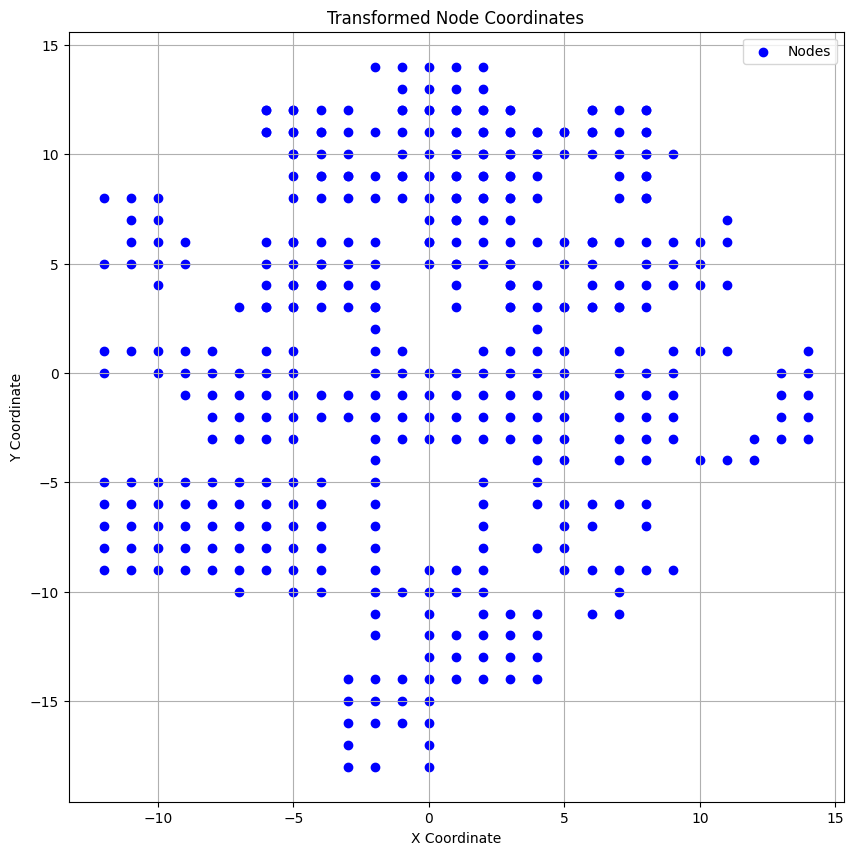

In [16]:
# Plotting
plt.figure(figsize=(10, 10))
plt.scatter(x_coords_tfm, y_coords_tfm, c='blue', label='Nodes')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Transformed Node Coordinates')
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipykernel_924795/1488580026.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 6))
/tmp/ipykernel_924795/1488580026.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Greys')


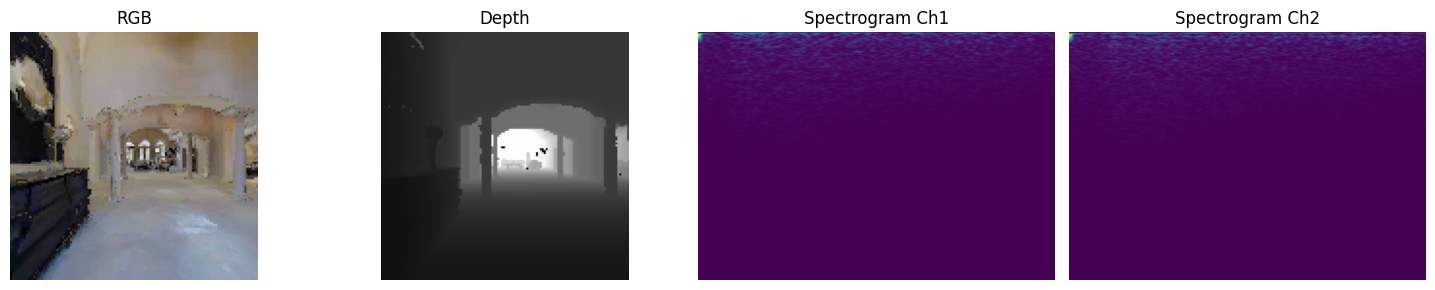

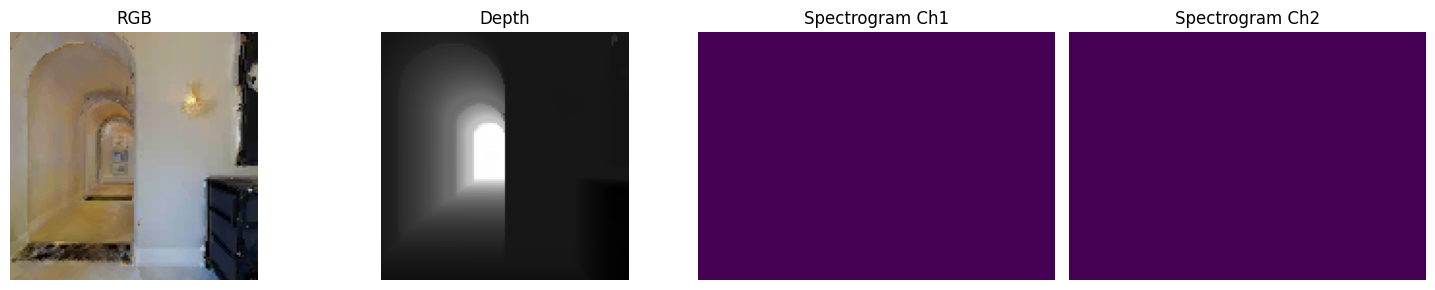

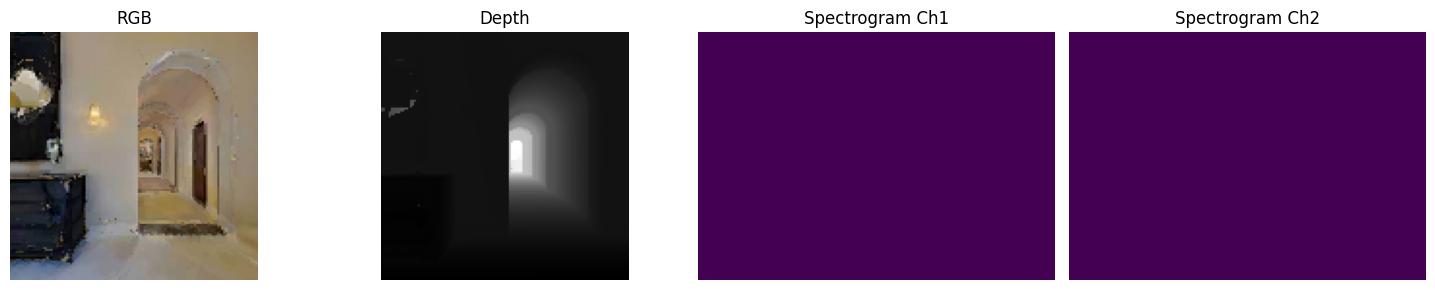

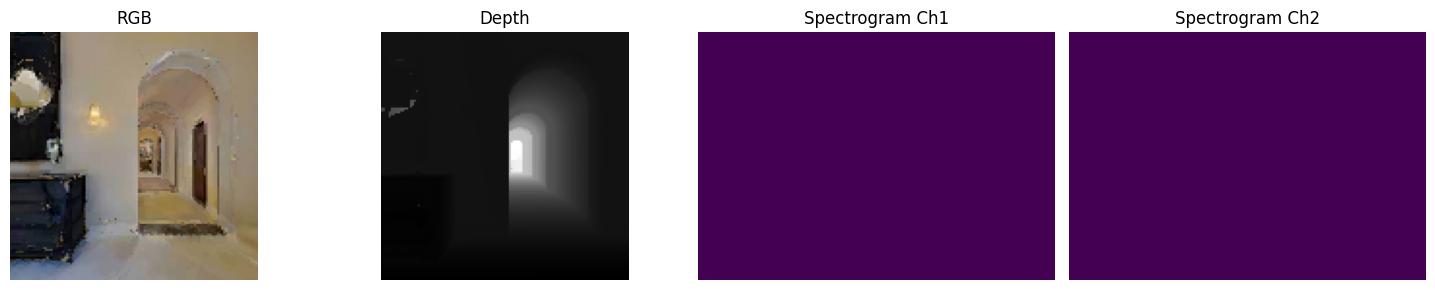

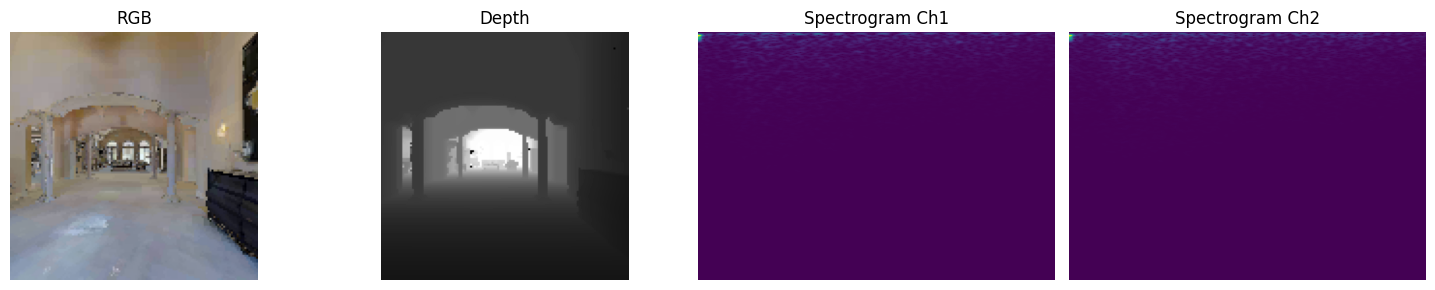

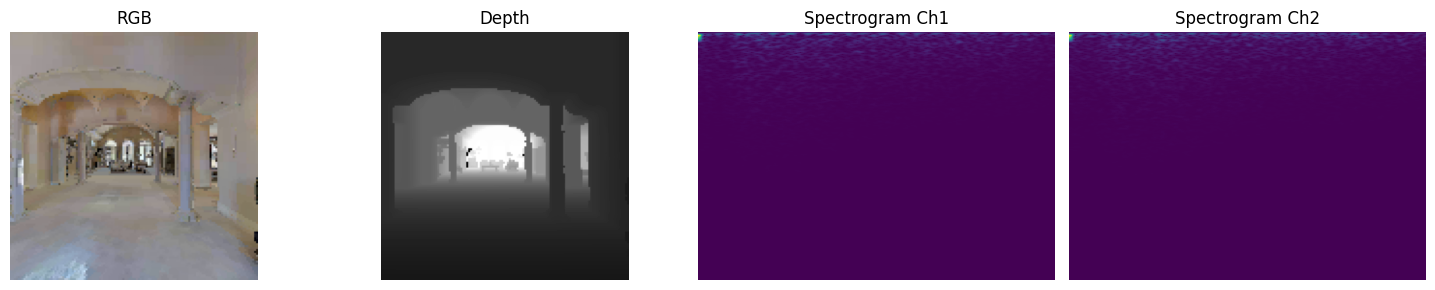

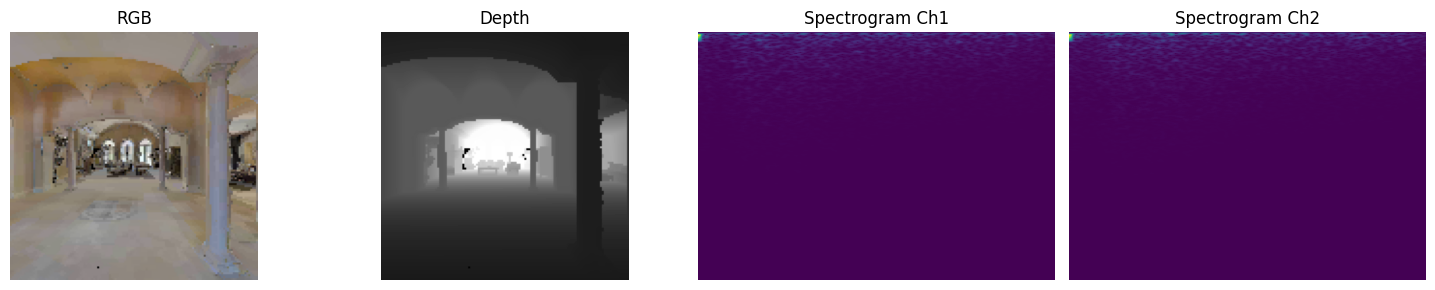

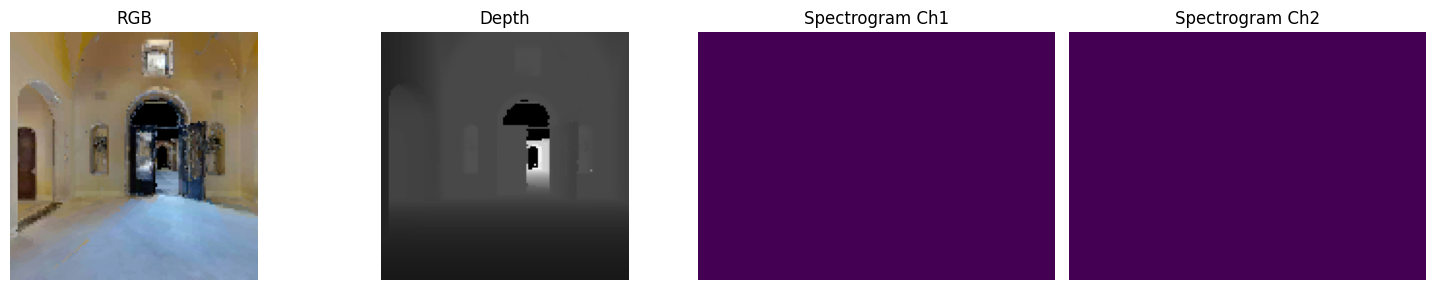

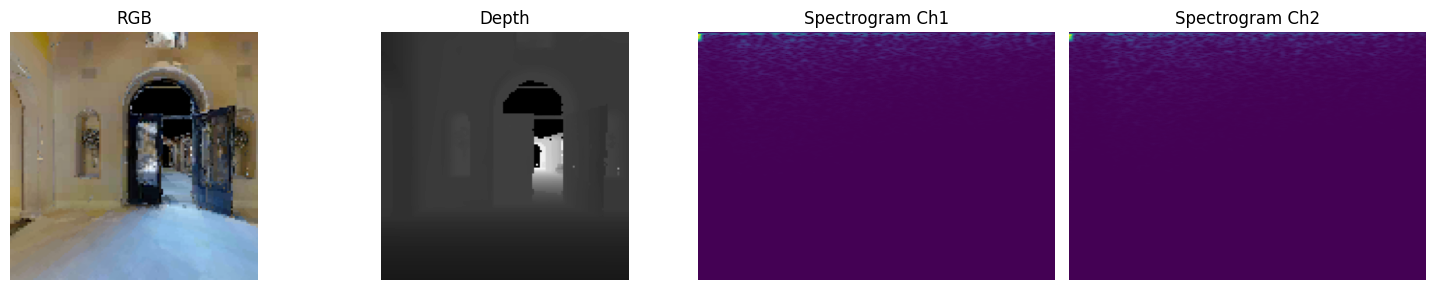

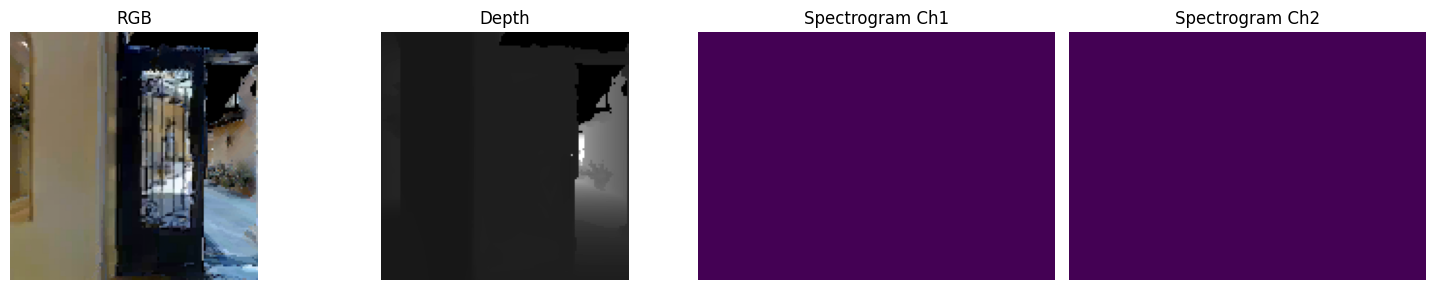

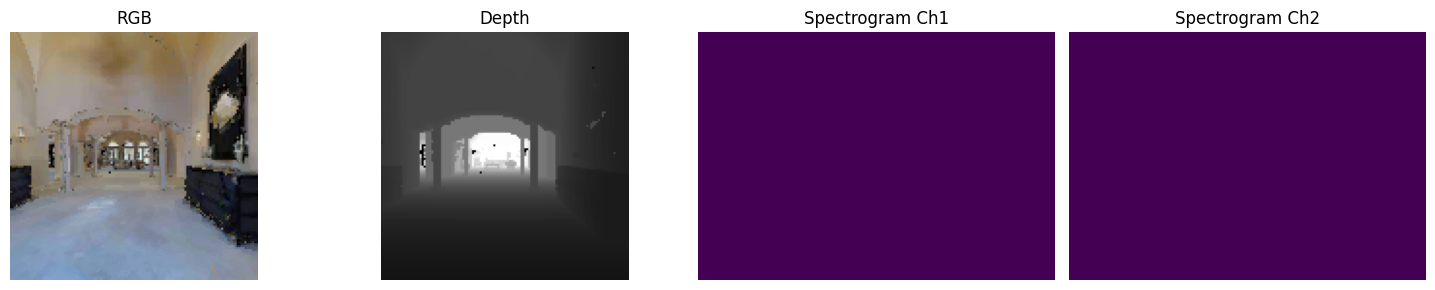

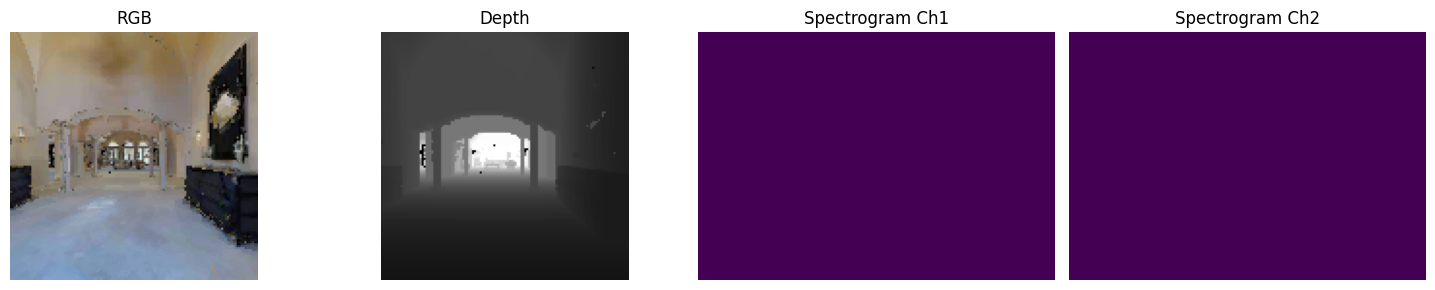

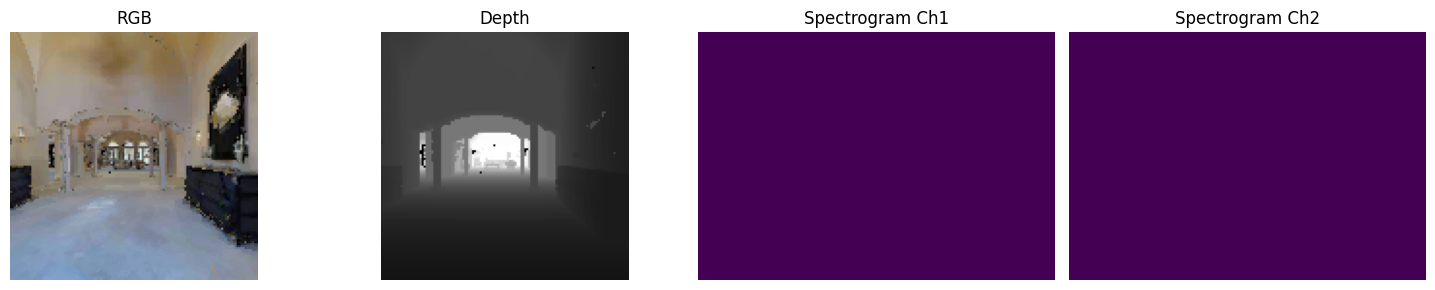

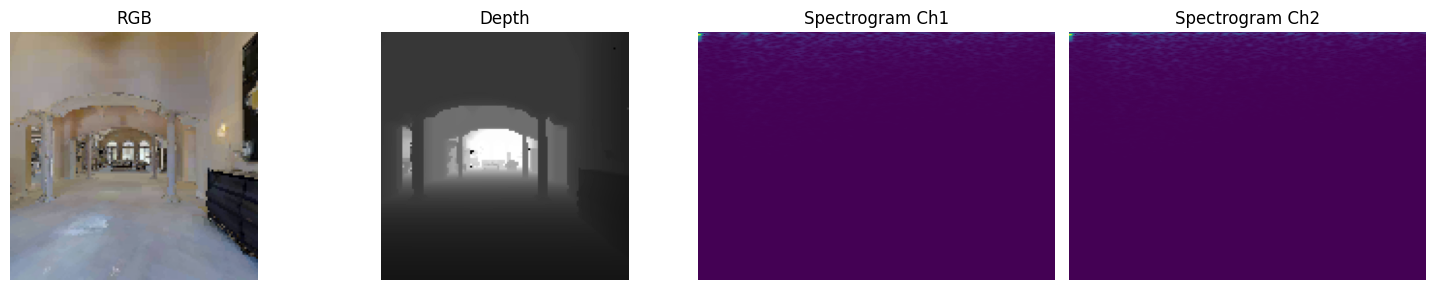

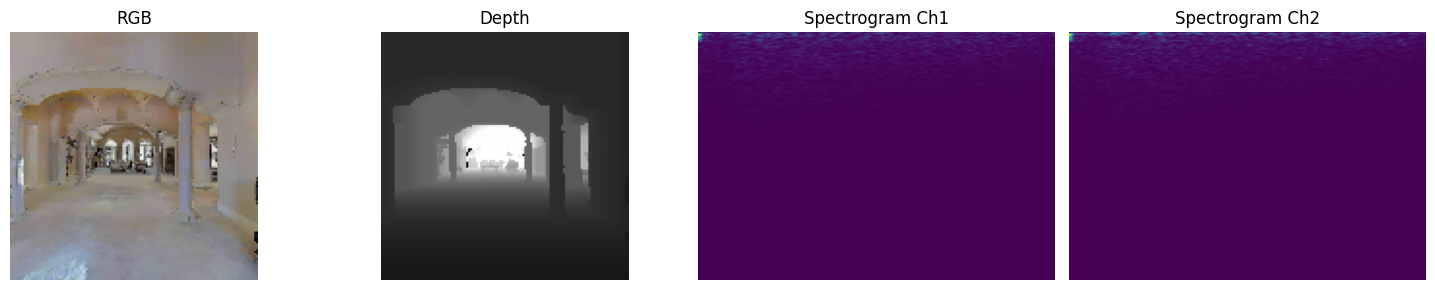

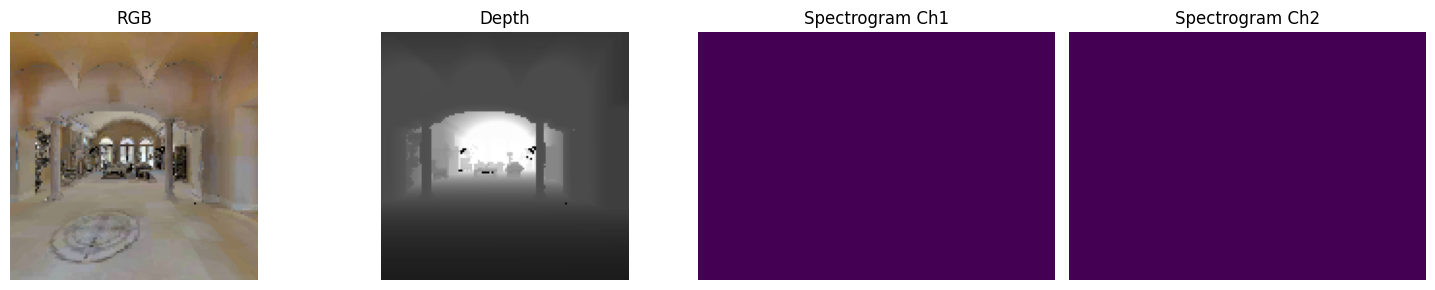

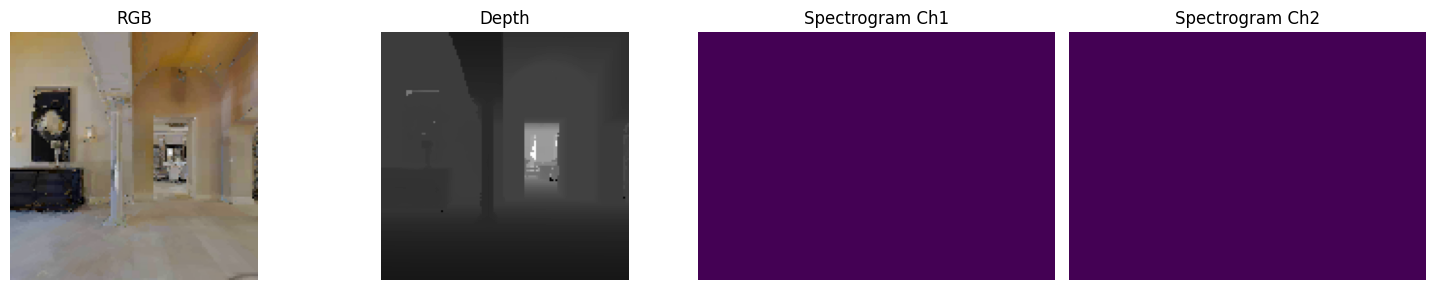

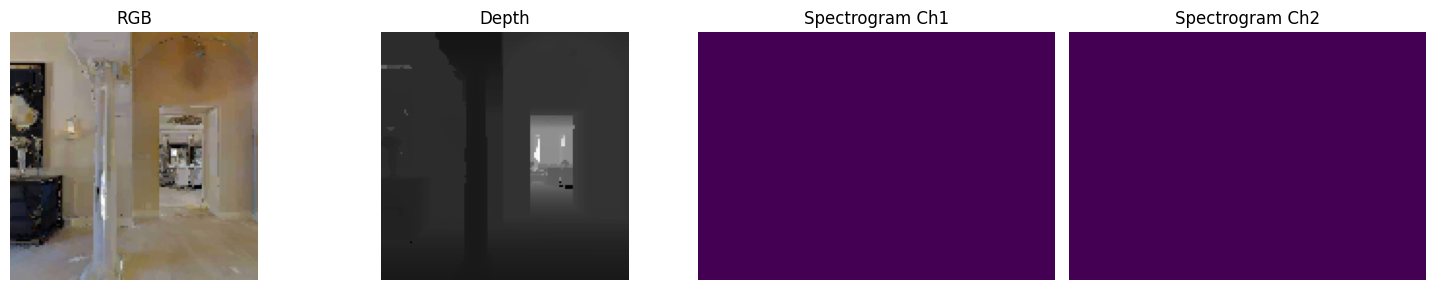

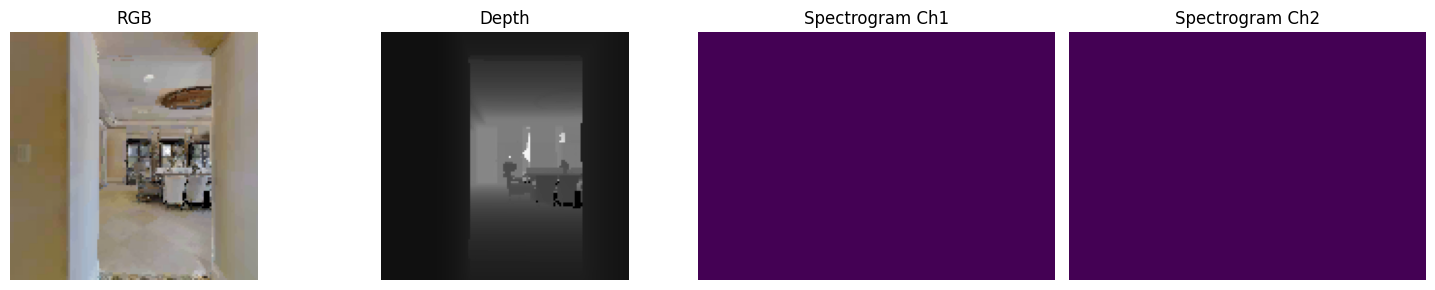

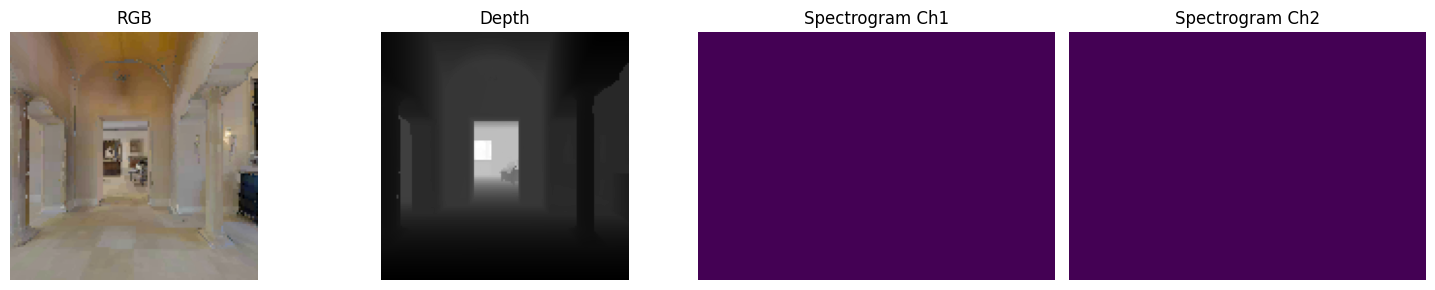

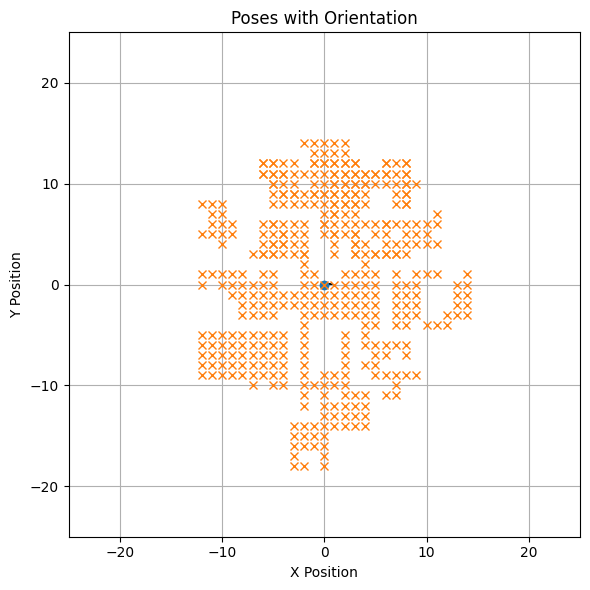

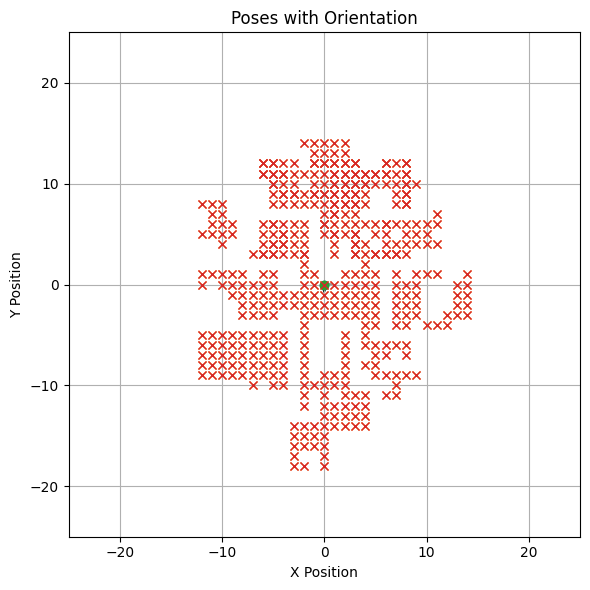

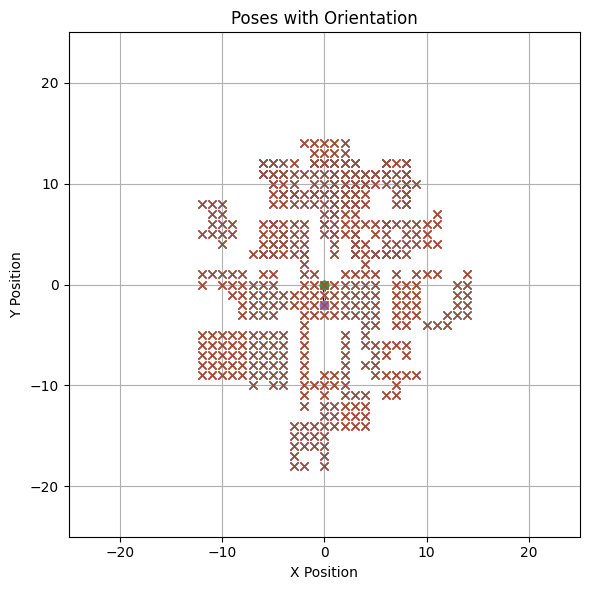

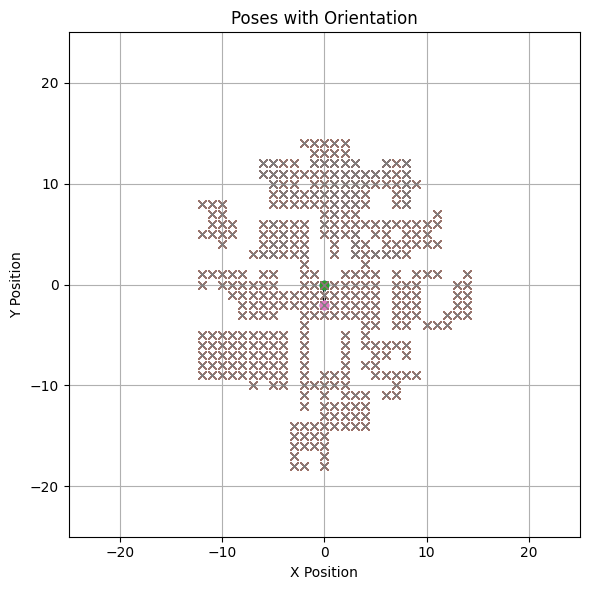

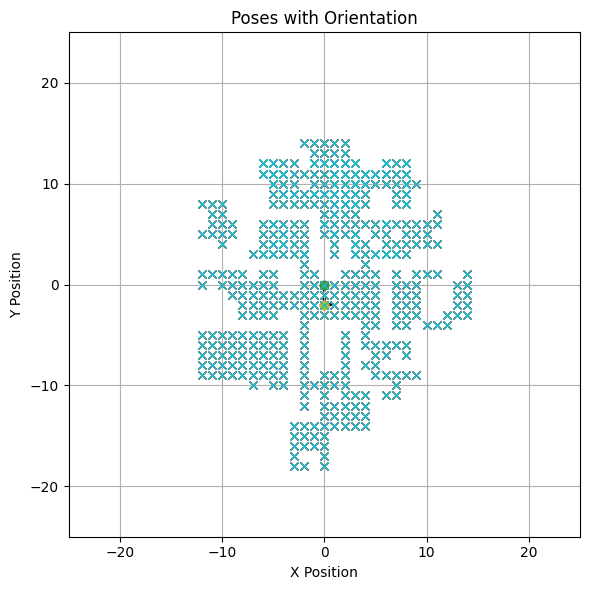

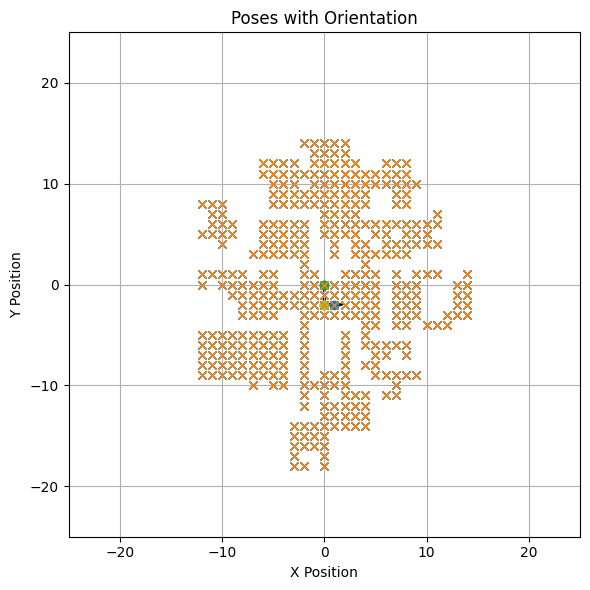

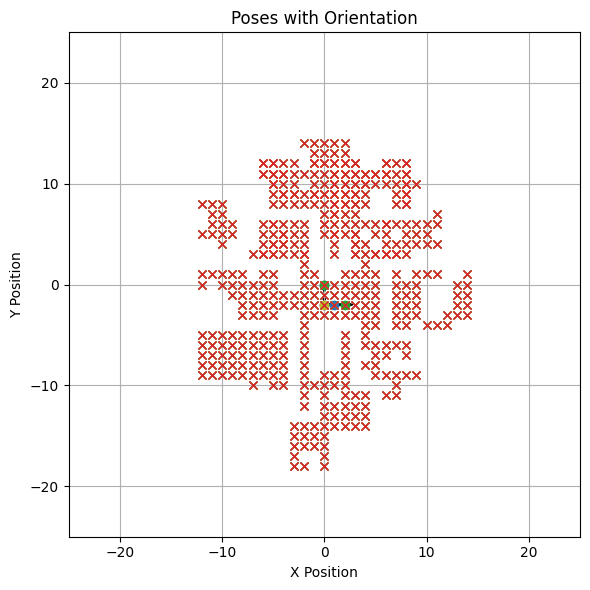

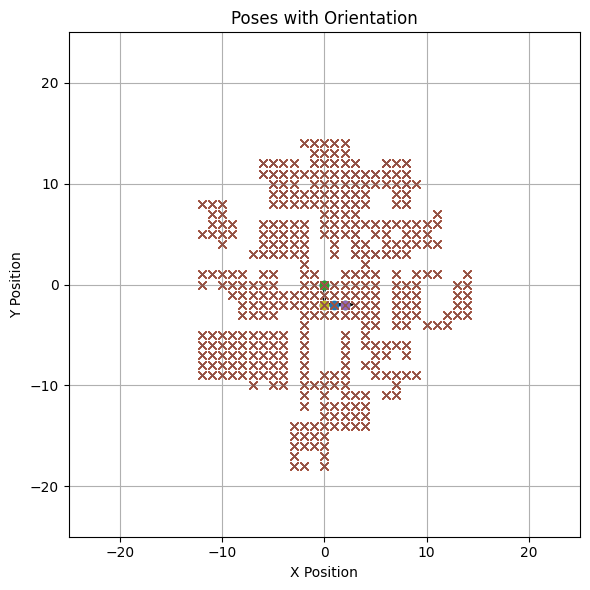

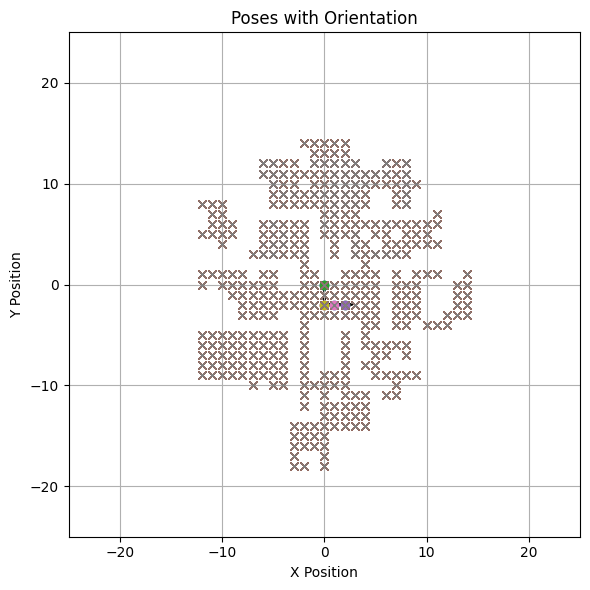

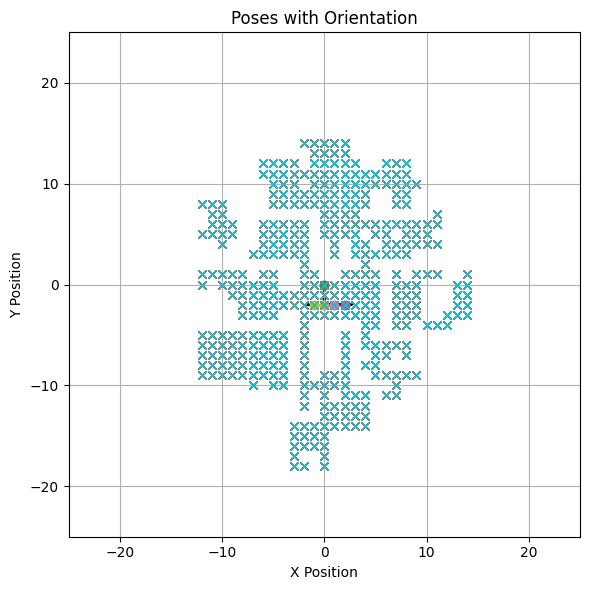

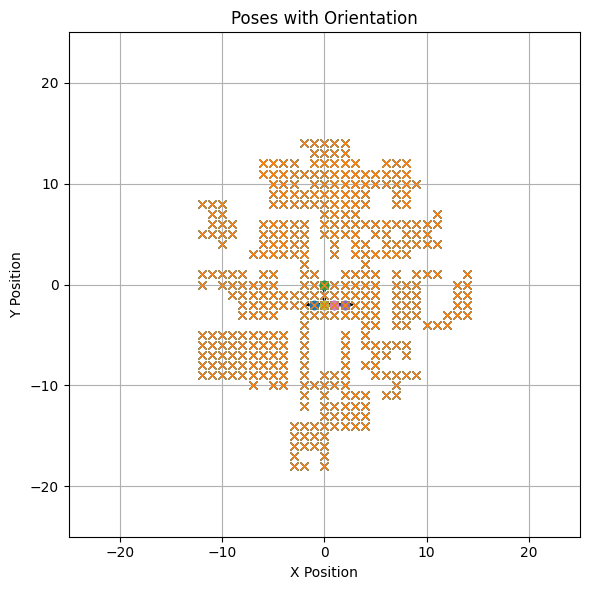

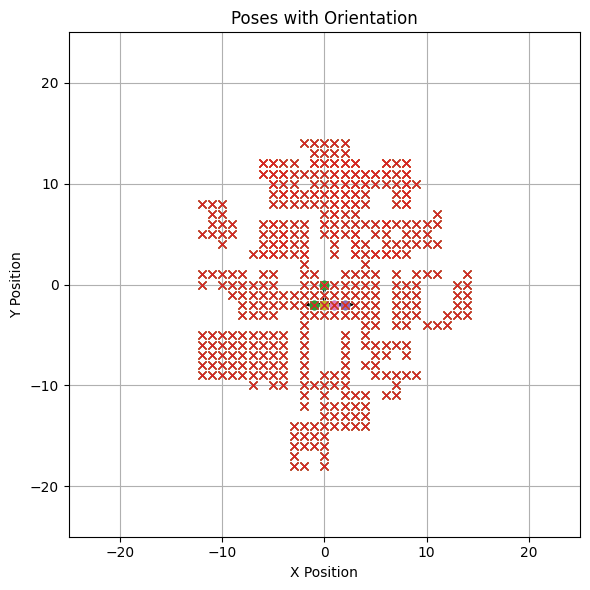

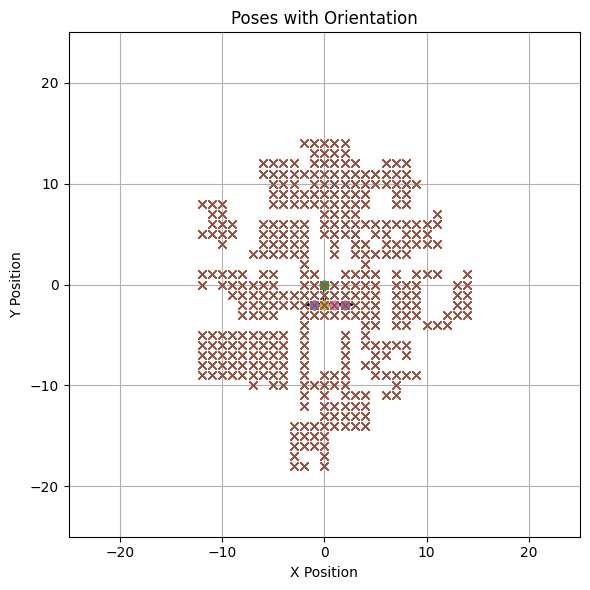

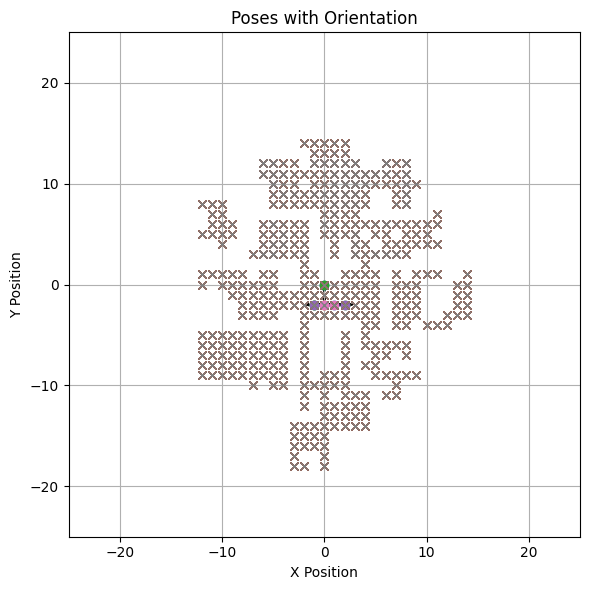

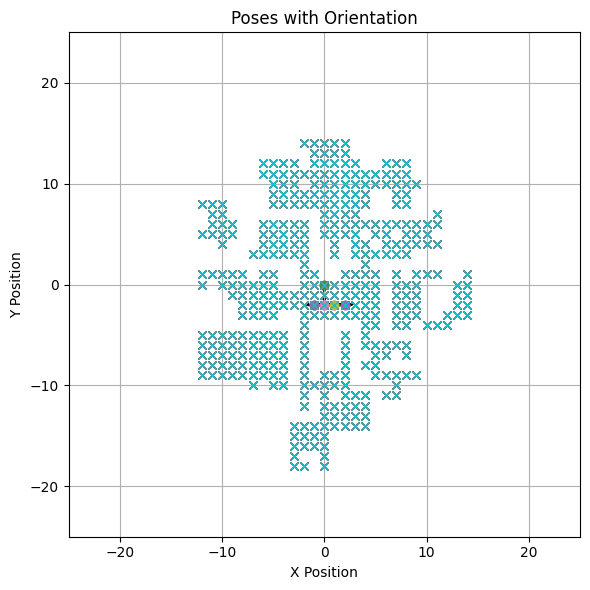

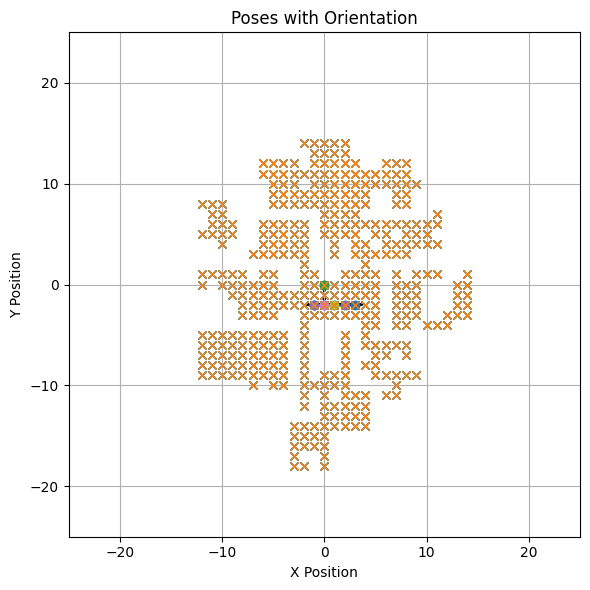

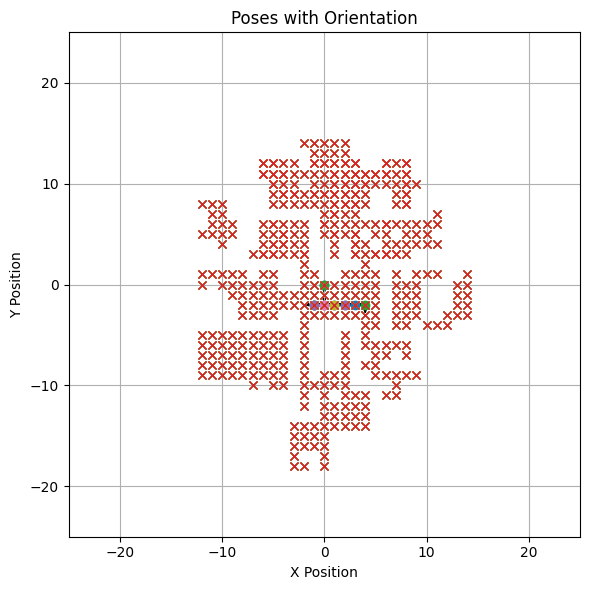

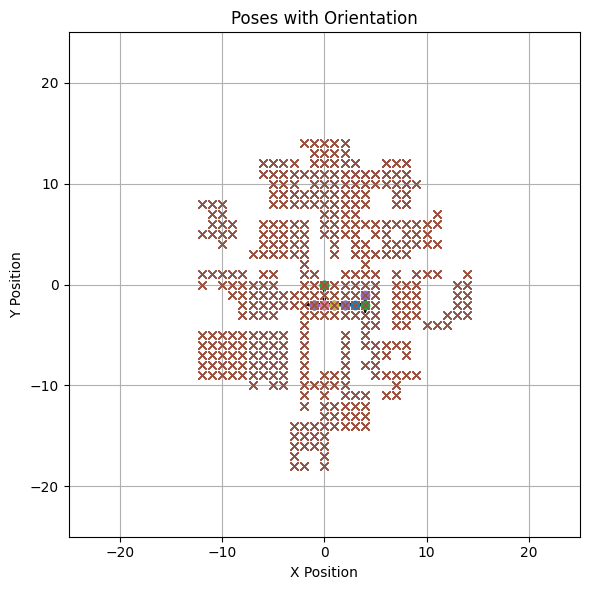

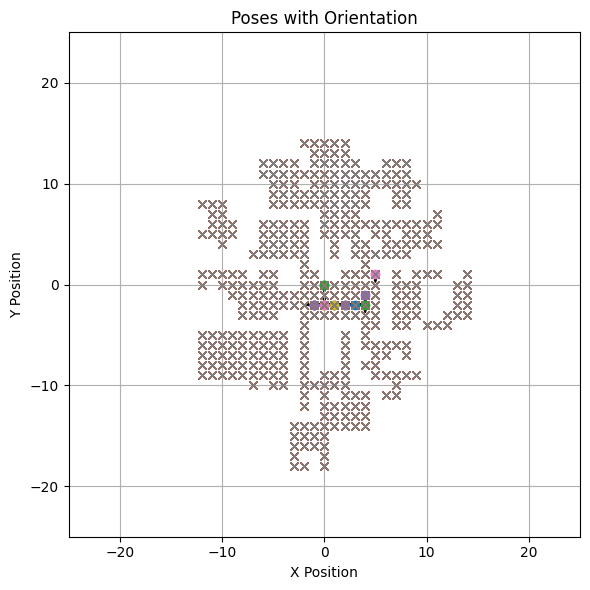

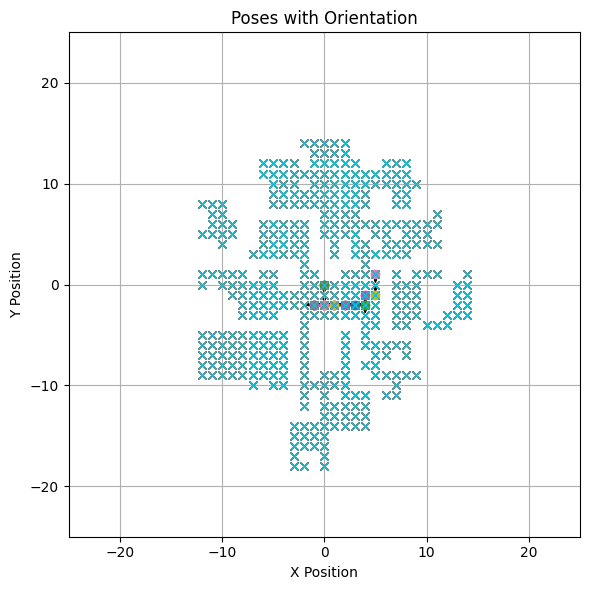

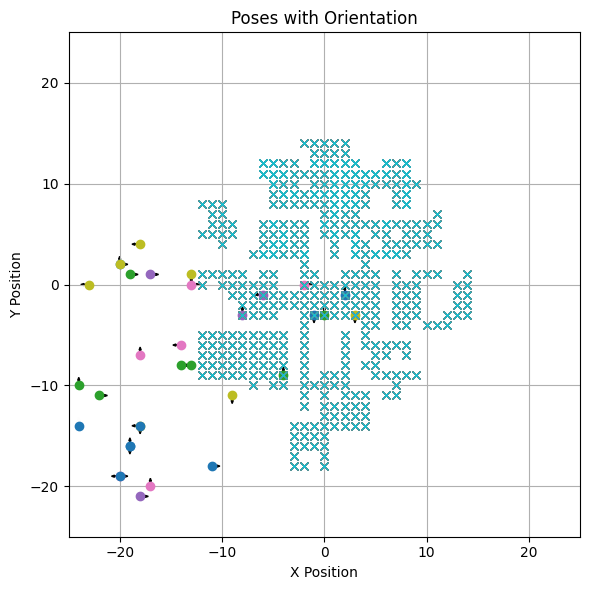

In [17]:
# Assuming mock_data is already created
# Visualize each item in the dataset
for item in loaded_list:
    plot_rgb_depth_spect(item['rgb'], item['depth'].squeeze(), item['bin_spect_mag'])

# Extracting and plotting pose data with orientation
pose_data = [item['pose'] for item in loaded_list]
for i in range(len(pose_data)):
    plot_poses_with_orientation(pose_data[:i+1], x_coords_tfm, y_coords_tfm, plot_line=False)

# Extracting and plotting pose data with orientation
plot_poses_with_orientation(np.array(query_poses), x_coords_tfm, y_coords_tfm, plot_line=False, pad=30)

# Show all plots
plt.show()

In [18]:
pose_data_true_positions = [[round(np.array(p)[0]), -round(np.array(p)[1])] for p in pose_data]
transformed_data = {key: [round(val[0]), round(val[1])] for key, val in transformed_data.items()}
intersecting_keys = set()

for key, value in transformed_data.items():
    for item in pose_data_true_positions:
        if value == item:
            print(value)
            print(item)
            intersecting_keys.add(key)
            print(len(intersecting_keys))

print("Node indices for NAF training:")
print(set(intersecting_keys))

[4, -2]
[4, -2]
1
[3, -2]
[3, -2]
2
[2, -2]
[2, -2]
3
[2, -2]
[2, -2]
3
[1, -2]
[1, -2]
4
[1, -2]
[1, -2]
4
[1, -2]
[1, -2]
4
[0, -2]
[0, -2]
5
[0, -2]
[0, -2]
5
[0, -2]
[0, -2]
5
[0, -2]
[0, -2]
5
[-1, -2]
[-1, -2]
6
[-1, -2]
[-1, -2]
6
[-1, -2]
[-1, -2]
6
[-1, -2]
[-1, -2]
6
[5, -1]
[5, -1]
7
[4, -1]
[4, -1]
8
[0, 0]
[0, 0]
9
[0, 0]
[0, 0]
9
[5, 1]
[5, 1]
10
Node indices for NAF training:
{258, 206, 207, 238, 180, 181, 182, 183, 184, 185}


In [19]:
print({key:transformed_data[key] for key in intersecting_keys})

{258: [5, 1], 206: [5, -1], 207: [4, -1], 238: [0, 0], 180: [4, -2], 181: [3, -2], 182: [2, -2], 183: [1, -2], 184: [0, -2], 185: [-1, -2]}


In [ ]:
import os
import random
import numpy as np
import librosa
from scipy.io import wavfile
import matplotlib.pyplot as plt

def load_wav_to_spectrogram(file_path):
    # Load the .wav file
    fs_imp, sig_imp = wavfile.read(file_path)

    if len(sig_imp) == 0:
            sig_imp = np.zeros((16000, 2)).astype("float32")
            fs_imp = 16000

    imp_full_length = np.zeros((16000, 2))

    if sig_imp.shape[0] > 128:
        imp_full_length[: min(sig_imp.shape[0], 16000) - 128] =\
            sig_imp[128: min(sig_imp.shape[0], 16000), :]    # remove the first 127 zero samples
    
    sig_imp = imp_full_length
    assert fs_imp == 16000
    sig_imp = sig_imp.T
    fft_windows_l_imp = librosa.stft(np.asfortranarray(sig_imp[0]),
                                        hop_length=62,
                                        n_fft=511,
                                        win_length=248 if (248 != 0) else None,)
    magnitude_l_imp, _ = librosa.magphase(fft_windows_l_imp)
    fft_windows_r_imp = librosa.stft(np.asfortranarray(sig_imp[1]),
                                        hop_length=62,
                                        n_fft=511,
                                        win_length=248 if (248 != 0) else None,)
    magnitude_r_imp, _ = librosa.magphase(fft_windows_r_imp)    
    magnitude_imp = np.stack([magnitude_l_imp, magnitude_r_imp], axis=-1)
    magnitude_imp = magnitude_imp.astype("float32")

    # Return the spectrogram
    return magnitude_imp

def display_spectrogram(spectrogram):
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))

    # Spectrogram Channel 1
    axes[0].imshow(spectrogram[:, :, 0].T, aspect='auto')
    axes[0].set_title('Spectrogram Ch1')
    axes[0].axis('off')

    # Spectrogram Channel 2
    axes[1].imshow(spectrogram[:, :, 1].T, aspect='auto')
    axes[1].set_title('Spectrogram Ch2')
    axes[1].axis('off')


# Directory containing the .wav files
directory = "/vision/asomaya1/active-rir/data/binaural_rirs/mp3d/Z6MFQCViBuw/0"

# Find all .wav files in the directory
wav_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.wav') and f.split("_")[-1].split(".")[0] == f.split("_")[0].split("/")[-1]]

# Randomly select 5 files
selected_files = random.sample(wav_files, 1)

# Process and display each file
for file in selected_files:
    spectrogram = load_wav_to_spectrogram(file)
    display_spectrogram(spectrogram)

In [ ]:
fs_rir_obs_path = "/vision/asomaya1/active-rir/fs_rir_context_obs.pkl"
with open(fs_rir_obs_path, "rb") as f:
    fs_rir_context_obs = pickle.load(f)

In [ ]:
fs_rir__preds_obs_path = "/vision/asomaya1/active-rir/fs_rir_context_obs_preds.pkl"
with open(fs_rir__preds_obs_path, "rb") as f:
    fs_rir_preds_obs = pickle.load(f)

In [ ]:
# Extract the relevant data
views = fs_rir_context_obs['context']['views']
echoes_mag = fs_rir_context_obs['context']['echoes_mag']
poses = fs_rir_context_obs['context']['poses']
query_poses = fs_rir_context_obs['query']['poses']

# Plot and save the visualizations
visualization_files = []
for i in range(views.shape[0]): #views.shape[0]
    rgb = views[i, :, :, :3]  # First three channels for RGB
    depth = views[i, :, :, 3]  # Fourth channel for Depth
    echoes = echoes_mag[i]

    plot_rgb_depth_spect(rgb, torch.tensor(depth), echoes)

pose_data = [pose for pose in poses]
for i in range(len(pose_data)):
    plot_poses_with_orientation(pose_data[:i+1], plot_line=False, pad=30)
plt.show()

In [ ]:
plot_poses_with_orientation(query_poses, plot_line=False)
plt.show()

In [ ]:
query_poses

In [ ]:
fs_rir_preds_obs = fs_rir_preds_obs.cpu().squeeze()

In [ ]:
plot_spectrograms_grid(pred_rirs)

In [ ]:
plot_spectrograms_grid(fs_rir_preds_obs)